<a href="https://colab.research.google.com/github/vg137/bert-dissection/blob/main/step_2_word_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Given a dataset of sentences, we first tokenize it using some subword tokenization scheme as discussed [here](https://colab.research.google.com/drive/1kC9GfuioCXGYFPs79qkCQ-ez9sLu8bqx?usp=sharing). Tokenization can be thought of as a preliminary embedding (or mapping) whose main job is to get a convert sentences to a sequence of number (i.e. token IDs). It also captures some information about sentences like finding out common subwords but still we need a richer representation.

To talk about representations, we need to define the input space of any transformer.
Any transformer can only deal with sequences which can have lengths upto a maximum value. This maximum length $L_\mathrm{max}$ of input sequences is called the **context length**, **context window** or maximum sequence length. So, the input space $S$ is the set of all sequences of token ids upto length $L_\mathrm{max}$ i.e.
$$S := \bigcup_{n = 1}^{L_\mathrm{max}} S_n$$
where
$$S_n := \{0, \dots, N_\mathrm{vocab} - 1\}^n$$
is the set of all sequences of length $n$, and $N_\mathrm{vocab}$ is the size of the vocabulary of the tokenization.

In [ ]:
import torch # huggingface is based on pytorch so we need pytorch to work with it
from transformers import AutoTokenizer, AutoModel # automatically gets the tokenizer and the model from a pretrained model in the huggingface library

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # getting the BERT tokenizer
model = AutoModel.from_pretrained("bert-base-uncased") # getting the BERT model

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Aside: finding out the details of a model

## Architecture

Let's see what this model looks like i.e. the model architecture. Any Hugging Face model is a PyTorch model so the default `print(model)` way to print PyTorch model summary works

In [ ]:
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Another way, specifically for Hugging Face models is to use `print(model.config)`.

In [ ]:
print(model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.15.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



From the above output, we can see that `max_position_embeddings` is 512. This effectively is the maximum sequence length $L_\mathrm{max}$ that the model can deal with.

## Methods

Let's see what can we do with this model by looking at all the methods associated with it.

In [ ]:
dir(model) # treats the argument as a directory of methods and prints them out

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_bias',
 '_adjust_missing_and_unexpected_keys',
 '_apply',
 '_auto_class',
 '_backward_compatibility_gradient_checkpointing',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_can_compile_fullgraph',
 '_can_record_outputs',
 '_can_set_attn_implementation',
 '_can_set_experts_implementation',
 '_can_set_experts_implementation_cached_value',
 '_check_and_adjust_attn_implementation',
 '_check_and_adjust_experts_implementation',
 '_compatible_flash_

These methods are very useful because they allow us to see the individual components of the models. For example: `named_children()` method gives us an iterator over individual immediate child modules of the model that we can see when we use `print(model)`.

In [ ]:
for module_name, module_details in model.named_children():
    print(module_name)

embeddings
encoder
pooler


So, BERT has three modules listed above. We can further look into the details for them by using their names as keys as follows

In [ ]:
print(model.embeddings)

BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


The output above is a list of all the layers in the `embeddings` module of the model.

# Embedding layer

Any map which acts on a token ID can be trivially extended to act on any sequence and, therefore, to all of $S$. We use this principle to define a richer representation by extending a map called **word embedding** which maps a token ID to a real vector in $\mathbb{R}^{N_\mathrm{embed}}$. Here, $\mathbb{R}^{N_\mathrm{embed}}$ is called the **embedding space** and $N_\mathrm{embed}$ is called the **embedding dimension**.

In neural networks, embedding is implement via an EmbeddingLayer whose weights take the form of a real-valued matrix $M$ of size $N_\mathrm{vocab} \times N_\mathrm{embed}$ called the **embedding matrix**. We define how the EmbeddingLayer acts on a sequence $s \in S_n$ as follows
$$s \mapsto (\mathrm{row}_{s_0}(M), \dots, \mathrm{row}_{s_{n-1}}(M))$$
where $s_i$ is the $i$<sup>th</sup> token ID in the sequence $s$. For a token ID $t$, the row matrix $\mathrm{row}_{t}(M) \in \mathbb{R}^{N_\mathrm{embed}}$ is called the **embedding vector** or the **word embedding** corresponding to the token ID $t$.

In other words, **embedding matrix** is just a lookup table. Just replace the token ID with the corresponding row of the table.

From the list of methods, we can use the `get_input_embeddings()` method to get the embedding layer of the model.

In [ ]:
embedding_layer = model.get_input_embeddings() # singling out the input embedding layer of BERT as a pytorch layer

In [ ]:
embedding_matrix = embedding_layer.weight.data # getting the embedding matrix

In [ ]:
print(f"The number of differnt token IDs that BERT recognizes is {embedding_matrix.shape[0]}")

The number of differnt token IDs that BERT recognizes is 30522


In [ ]:
embedding_matrix.shape[0] == tokenizer.vocab_size

True

So, the number of rows of the embedding matrix is the same as $N_\mathrm{vocab}$ (as we discussed above)

In [ ]:
print(f"The embedding dimension of BERT is {embedding_matrix.shape[1]}")

The embedding dimension of BERT is 768


Let us check that the `embedding_layer` just returns the corresponding row from the embedding matrix.

In [ ]:
# first, we get a random token id in pytorch tensor form
input_token_id = torch.randint(0, embedding_layer.num_embeddings, (1,)) # embedding_layer.num_embeddings also gets the vocab size
print(input_token_id)

tensor([22165])


Because `embedding_layer` is a pytorch layer, it only accepts pytorch tensors as inputs. That's why `torch.randint` is used instead of non-PyTorch options.

In [ ]:
# second, let's get the embedding vector corresponding to the above token id
embedding_vector = embedding_layer(input_token_id)

In [ ]:
# third, we compare the above embedding_vector with the correspoding row of the embedding_matrix
comparison = embedding_matrix[input_token_id] == embedding_vector # returns a long pytorch tensor of booleans
print(bool(comparison.all())) # Use .all() to get a single boolean

True


They are exactly the same vector.

## Semantically close tokens

The whole purpose of embedding is to get assign some semantic value to similar tokens. Let's see whether it achieves this.

In [ ]:
similar_words = ['run', 'runs', 'ran', 'running'] # all these are assigned a single token (i.e. they are single-token sequences)
similar_words_token_ids = tokenizer.encode(similar_words)

In [ ]:
print(similar_words_token_ids)

[[101, 2448, 102], [101, 3216, 102], [101, 2743, 102], [101, 2770, 102]]


For each word, we got three token IDs. But the first and the last one are the same for all the words. Let's see which tokens do these IDs represent.

In [ ]:
tokenizer.decode([101, 102])

'[CLS] [SEP]'

These are just special tokens that we saw in the previous notebook. We will ignore them and just work with the middle tokens.

In [ ]:
middle_token_ids = [token_list[1] for token_list in similar_words_token_ids]
print(middle_token_ids)

[2448, 3216, 2743, 2770]


Note that even though the words are quite similar, the token IDs are not. Let's also see the two neighbouring tokens for these token ids.

In [ ]:
for token_id in middle_token_ids:
    print(tokenizer.decode(token_id - 1), tokenizer.decode(token_id), tokenizer.decode(token_id + 1))

player run business
##ts runs ##ro
example ran term
money running mi


We see that these are completely different. So, the distances between token ids carry no semantic meaning (as expected). What about the embeddings?

In [ ]:
embedding_vectors = embedding_layer(torch.tensor(middle_token_ids))
print(embedding_vectors.shape)

torch.Size([4, 768])


We want to see how close these vectors are to each other in the embedding space. To do this, we can find the Euclidean distance between two vectors

In [ ]:
for i in range(embedding_vectors.shape[0]):
    for j in range(i + 1, embedding_vectors.shape[0]):
        distance = torch.norm(embedding_vectors[i] - embedding_vectors[j])
        print(distance.data)

tensor(0.8753)
tensor(0.9730)
tensor(0.9272)
tensor(0.8465)
tensor(0.9148)
tensor(0.8714)


We can compare these to the distances between neighbouring tokens IDs

In [ ]:
for i in range(len(middle_token_ids) - 1):
    previous_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i] - 1)).data
    current_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i])).data
    next_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i] + 1)).data
    distance_from_previous_token = torch.norm(previous_embedding_vector - current_embedding_vector)
    distance_from_next_token = torch.norm(current_embedding_vector - next_embedding_vector)
    print(distance_from_previous_token, distance_from_next_token)

tensor(1.3966) tensor(1.3423)
tensor(1.3645) tensor(1.4234)
tensor(1.4548) tensor(1.3721)


We can also see which are the closest words to a given word.

These are clearly larger than the those between similar words. But let us also check the angles (or cosine similarity) between them. The formula for the angle between two vectors $v_1, v_2 \in \mathbb{R}^n$ is
$$\cos\theta = \Bigg(\frac{v_1 \cdot v_2}{||v_1|| ||v_2||}\Bigg)$$

In [ ]:
# torch.nn.functional submodule has an inbuilt cosine similarity function
import torch.nn.functional as F

In [ ]:
for i in range(embedding_vectors.shape[0]):
    for j in range(i + 1, embedding_vectors.shape[0]):
        cosine_similarity = F.cosine_similarity(embedding_vectors[i], embedding_vectors[j], dim=0)
        print(cosine_similarity.data)

tensor(0.6845)
tensor(0.6110)
tensor(0.6520)
tensor(0.6909)
tensor(0.6450)
tensor(0.6789)


In [ ]:
for i in range(len(middle_token_ids) - 1):
    previous_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i] - 1)).data
    current_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i])).data
    next_embedding_vector = embedding_layer(torch.tensor(middle_token_ids[i] + 1)).data

    cosine_similarity_with_previous_vector = F.cosine_similarity(previous_embedding_vector, current_embedding_vector, dim=0)
    cosine_similarity_with_next_vector = F.cosine_similarity(next_embedding_vector, current_embedding_vector, dim=0)

    print(cosine_similarity_with_previous_vector, cosine_similarity_with_next_vector)

tensor(0.1660) tensor(0.2572)
tensor(0.3411) tensor(0.3098)
tensor(0.1770) tensor(0.2256)


Now, the difference is even more drastic. So, a properly trained EmbeddingLayer does impart some notion of closeness to semantically similar words.

A more interesting and informative way to see how similar words are closer together in the embedding space is to see the nearest-neighbors of a given word. Let us see what this yields.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
### Function definitions to generate the nearest-neighbors graph for a word

def closest_words(token, k=5, metric='cos', search_pool=300):
    """
    Return the k closest non-special, non-WordPiece-continuation tokens
    to a given BERT token, using either 'cos' (cosine) or 'euc' (euclidean).
    """
    token_id = tokenizer.convert_tokens_to_ids(token)

    if token_id == tokenizer.unk_token_id:
        raise ValueError(f"{token!r} is not in the BERT vocabulary.")

    query = embedding_matrix[token_id]

    if metric == 'cos':
        E_norm = embedding_matrix / torch.norm(embedding_matrix, dim=1, keepdim=True)
        query_norm = query / torch.norm(query)
        sims = E_norm @ query_norm
        values, indices = torch.topk(sims, k=search_pool, largest=True)
    elif metric == 'euc':
        distances = torch.norm(embedding_matrix - query, dim=1)
        values, indices = torch.topk(distances, k=search_pool, largest=False)
    else:
        raise ValueError("Metric must be 'cos' or 'euc'")

    neighbors = []

    for score, idx in zip(values, indices):
        idx = idx.item()
        score = score.item()
        neighbor = tokenizer.convert_ids_to_tokens(idx)

        # Filter out self, special tokens, WordPieces, and [unused***] placeholders
        if (
            idx == token_id or
            neighbor in tokenizer.all_special_tokens or
            neighbor.startswith("##") or
            neighbor.startswith("[unused")
        ):
            continue

        neighbors.append((neighbor, idx, score))
        if len(neighbors) == k:
            break

    return neighbors

def build_neighbor_graph(start_token, k=5, depth=2, metric='cos'):
    """
    Build a graph using specified metric: 'cos' or 'euc'.
    Ensures node attributes (like depth) are locked at the first encounter.
    """
    G = nx.Graph()
    node_depths = {start_token: 0}
    G.add_node(start_token, depth=0)

    visited = set()
    frontier = [(start_token, 0)]

    while frontier:
        token, d = frontier.pop(0)
        if token in visited:
            continue

        visited.add(token)

        if d >= depth:
            continue

        for neighbor, neighbor_id, score in closest_words(token, k=k, metric=metric):
            if neighbor not in node_depths:
                node_depths[neighbor] = d + 1
                G.add_node(neighbor, depth=d + 1)
                frontier.append((neighbor, d + 1))

            G.add_edge(token, neighbor, weight=score)

    return G

def plot_neighbor_graph(
    G,
    figsize=(10, 7),
    show_edge_labels=False,
    layout_seed=0,
    layout_k=1.6,
    layout_iterations=200,
    node_padding=1.25,
    title="BERT Embedding Nearest-Neighbor Graph",
):
    """
    Visualize the nearest-neighbor graph with a cleaner publication-style layout.

    node_padding controls the extra space around labels inside nodes.
    layout_k controls the spacing between nodes.
    """
    fig, ax = plt.subplots(figsize=figsize)

    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        k=layout_k,
        iterations=layout_iterations,
        weight=None,
    )

    depths = nx.get_node_attributes(G, "depth")

    depth_colors = {
        0: "#1f2937",
        1: "#2563eb",
        2: "#14b8a6",
        3: "#a855f7",
    }

    depth_sizes = {
        0: 1800,
        1: 1100,
        2: 750,
        3: 550,
    }

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#9ca3af",
        width=1.2,
        alpha=0.45,
    )

    max_depth = max(depths.values()) if depths else 0

    for depth in range(max_depth + 1):
        nodes_at_depth = [
            node for node in G.nodes()
            if depths.get(node, max_depth) == depth
        ]

        if not nodes_at_depth:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes_at_depth,
            node_size=depth_sizes.get(depth, 500) * node_padding**2,
            node_color=depth_colors.get(depth, "#d1d5db"),
            edgecolors="white",
            linewidths=1.8,
            alpha=0.95,
            ax=ax,
            label=f"depth {depth}",
        )

    labels = {node: node for node in G.nodes()}

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_weight="medium",
        font_family="sans-serif",
        font_color="#111827",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.18",
        ),
        ax=ax,
    )

    if show_edge_labels:
        edge_weights = nx.get_edge_attributes(G, "weight")
        edge_labels = {
            edge: f"{weight:.2f}"
            for edge, weight in edge_weights.items()
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=7,
            font_color="#374151",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                boxstyle="round,pad=0.12",
            ),
            ax=ax,
        )

    ax.set_title(title)
    ax.margins(0.12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=18,
        color="#111827",
    )

    ax.legend(
        loc="upper left",
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="#e5e7eb",
        fontsize=9,
        handletextpad=1.6,
    )

    ax.set_axis_off()
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    plt.tight_layout()
    plt.show()

In [ ]:
tokenizer.encode("mundane")

[101, 24684, 102]

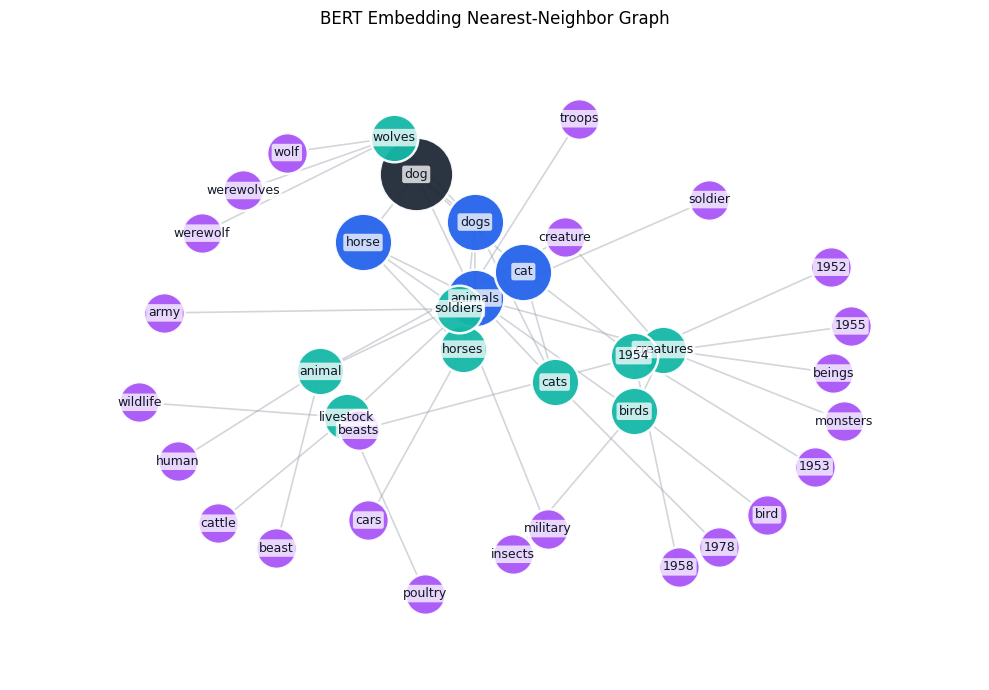

<Figure size 640x480 with 0 Axes>

In [ ]:
G = build_neighbor_graph(
    start_token="dog",
    k=4,
    depth=3,
    metric="euc"
)

plot_neighbor_graph(G, layout_k=3)

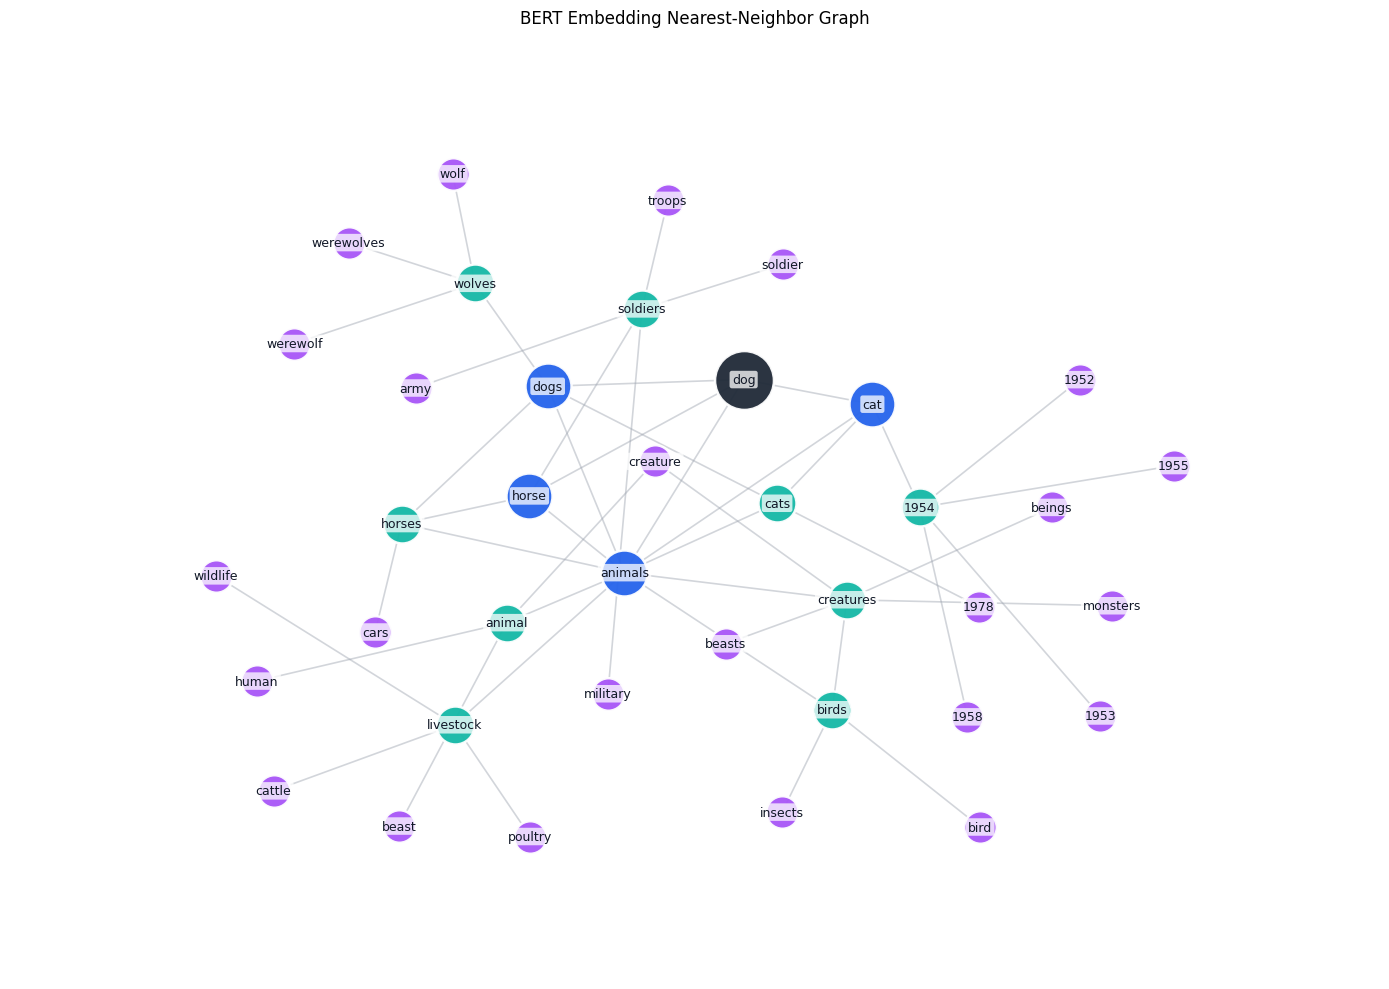

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


def separate_nodes(pos, min_distance=0.22, iterations=300):
    """
    Push nodes apart until their centers are at least min_distance apart.
    """
    nodes = list(pos)
    positions = np.array([pos[node] for node in nodes], dtype=float)

    rng = np.random.default_rng(0)

    for _ in range(iterations):
        displacement = np.zeros_like(positions)
        overlap_found = False

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                delta = positions[i] - positions[j]
                distance = np.linalg.norm(delta)

                if distance < min_distance:
                    overlap_found = True

                    if distance < 1e-12:
                        direction = rng.normal(size=2)
                        direction /= np.linalg.norm(direction)
                        distance = 1e-12
                    else:
                        direction = delta / distance

                    push = 0.5 * (min_distance - distance)
                    displacement[i] += push * direction
                    displacement[j] -= push * direction

        positions += displacement

        if not overlap_found:
            break

    return {
        node: positions[i]
        for i, node in enumerate(nodes)
    }


def plot_neighbor_graph(
    G,
    figsize=(12, 9),
    show_edge_labels=False,
    layout_seed=0,
    layout_k=1.6,
    layout_iterations=200,
    node_padding=1.0,
    node_separation=0.22,
    title="BERT Embedding Nearest-Neighbor Graph",
):
    fig, ax = plt.subplots(figsize=figsize)

    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        k=layout_k,
        iterations=layout_iterations,
        weight=None,
    )

    # spring_layout ignores the rendered node sizes, so remove collisions manually
    pos = separate_nodes(
        pos,
        min_distance=node_separation,
        iterations=300,
    )

    depths = nx.get_node_attributes(G, "depth")

    depth_colors = {
        0: "#1f2937",
        1: "#2563eb",
        2: "#14b8a6",
        3: "#a855f7",
    }

    depth_sizes = {
        0: 1800,
        1: 1100,
        2: 750,
        3: 550,
    }

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#9ca3af",
        width=1.2,
        alpha=0.45,
    )

    max_depth = max(depths.values()) if depths else 0

    for depth in range(max_depth + 1):
        nodes_at_depth = [
            node
            for node in G.nodes()
            if depths.get(node, max_depth) == depth
        ]

        if not nodes_at_depth:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes_at_depth,
            node_size=depth_sizes.get(depth, 500) * node_padding**2,
            node_color=depth_colors.get(depth, "#d1d5db"),
            edgecolors="white",
            linewidths=1.8,
            alpha=0.95,
            ax=ax,
            label=f"depth {depth}",
        )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={node: node for node in G.nodes()},
        font_size=9,
        font_weight="medium",
        font_family="sans-serif",
        font_color="#111827",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.18",
        ),
        ax=ax,
    )

    if show_edge_labels:
        edge_weights = nx.get_edge_attributes(G, "weight")
        edge_labels = {
            edge: f"{weight:.2f}"
            for edge, weight in edge_weights.items()
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=7,
            font_color="#374151",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                boxstyle="round,pad=0.12",
            ),
            ax=ax,
        )

    ax.set_title(title)
    ax.margins(0.15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_neighbor_graph(
    G,
    layout_k=2,
    node_separation=0.3,
    figsize=(14, 10),
)

It is clear that some sense of a meaning and context for the words is being learnt during the training.

## How to deal with sequences of different lengths?

If we have a bunch of sentences of different lengths like

In [ ]:
example_sequences = ["hello, how are you?",
                     "hello",
                     "Hello, how are you? I am fine. What's up?"]

In [ ]:
example_sequences_token_ids = tokenizer(example_sequences, padding=True, return_tensors='pt').input_ids
print(example_sequences_token_ids)

tensor([[ 101, 7592, 1010, 2129, 2024, 2017, 1029,  102,    0,    0,    0,    0,
            0,    0,    0,    0,    0],
        [ 101, 7592,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0],
        [ 101, 7592, 1010, 2129, 2024, 2017, 1029, 1045, 2572, 2986, 1012, 2054,
         1005, 1055, 2039, 1029,  102]])


Note that the `padding=True` adds 0 token IDs to the sequences to match the length of the longest sequence in the list. The `return_tensors='pt'` option automatically converts the list to a PyTorch tensor. See below.

Let's see which token does the 0 token ID correspond to?

In [ ]:
tokenizer.decode(0)

'[PAD]'

So, it is a special token used exclusively for padding sequences.

In [ ]:
embedded_sequences = embedding_layer(example_sequences_token_ids)
print(embedded_sequences.shape)

torch.Size([3, 17, 768])


This confirms that we have 3 sequences of 17 tokens and each of them gets embedded in $\mathbb{R}^{768}$

`embedding_layer` being a PyTorch layer, only accepts PyTorch tensor inputs. A list of token ID sequences can only be converted to a PyTorch tensor if all sequences are of equal length. This is the reason why we have to `padding=True` and `return_tensors='pt'` options when we use `tokenizer.encode()` function above.